In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


## 1: Data Integration & Library Setup

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.sparse import hstack

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

## Data Loading



In [3]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print(train_df.shape, test_df.shape)

(198000, 15) (102000, 14)


## 2: Exploratory Data Analysis & Feature identification

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [5]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [6]:
import regex as re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["comment_clean"] = train_df["comment"].apply(clean_text)
test_df["comment_clean"]  = test_df["comment"].apply(clean_text)

for df in [train_df, test_df]:
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df["year"] = df["created_date"].dt.year.fillna(0).astype(int)
    df["month"] = df["created_date"].dt.month.fillna(0).astype(int)

    df["comment_clean"] = df["comment"].apply(clean_text)

In [7]:
for df in [train_df, test_df]:
    df['hour'] = df['created_date'].dt.hour.fillna(0).astype(int)
    df['day'] = df['created_date'].dt.dayofweek.fillna(0).astype(int)

    df['comment_length'] = df['comment_clean'].apply(len)
    df['word_count'] = df['comment_clean'].apply(lambda x: len(x.split()))
    df['unique_word_count'] = df['comment_clean'].apply(lambda x: len(set(x.split())))

    df['upvote_ratio'] = df['upvote'] / (df['downvote'] + 1)
    df['vote_diff'] = df['upvote'] - df['downvote']

    df['has_exclamation'] = df['comment_clean'].str.contains('!').astype(int)
    df['has_question'] = df['comment_clean'].str.contains('\?').astype(int)

    df['emoticon_total'] = df[['emoticon_1','emoticon_2','emoticon_3']].sum(axis=1)

In [8]:
# Target
y = train_df["label"]

# Features
feature_cols = [
    "comment_clean",
    "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2",
    "race", "religion", "gender", "disability",
    "year", "month",
    "hour", "day",
    "comment_length", "word_count", "unique_word_count",
    "upvote_ratio", "vote_diff",
    "emoticon_total"
]
X = train_df[feature_cols]
X_test = test_df[feature_cols]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)


(158400, 22) (39600, 22)


In [10]:
label_counts = train_df['label'].value_counts(normalize=True)
print("Target Distribution:\n", label_counts)

print(train_df[['upvote', 'downvote']].describe())

Target Distribution:
 label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64
              upvote       downvote
count  198000.000000  198000.000000
mean        2.607975       0.666394
std         5.054763       2.044335
min         0.000000       0.000000
25%         0.000000       0.000000
50%         1.000000       0.000000
75%         3.000000       1.000000
max       201.000000     107.000000


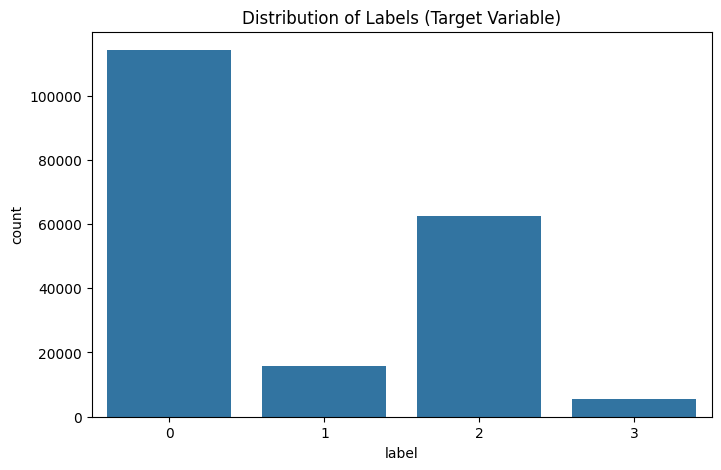

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label')
plt.title("Distribution of Labels (Target Variable)")
plt.show()


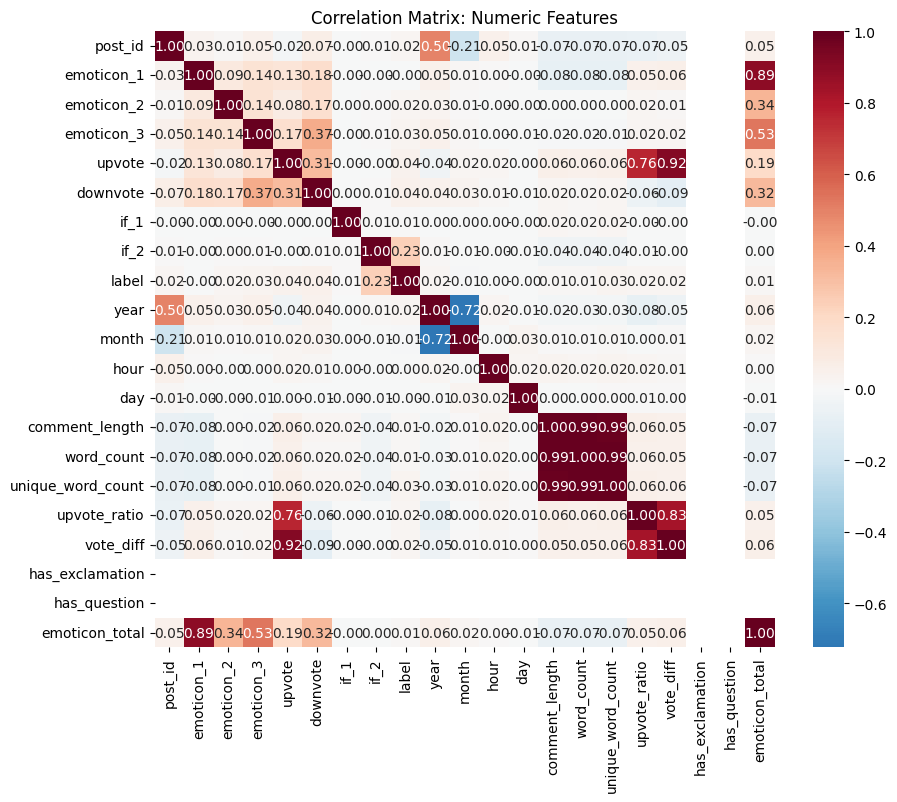

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation Matrix: Numeric Features")
plt.show()

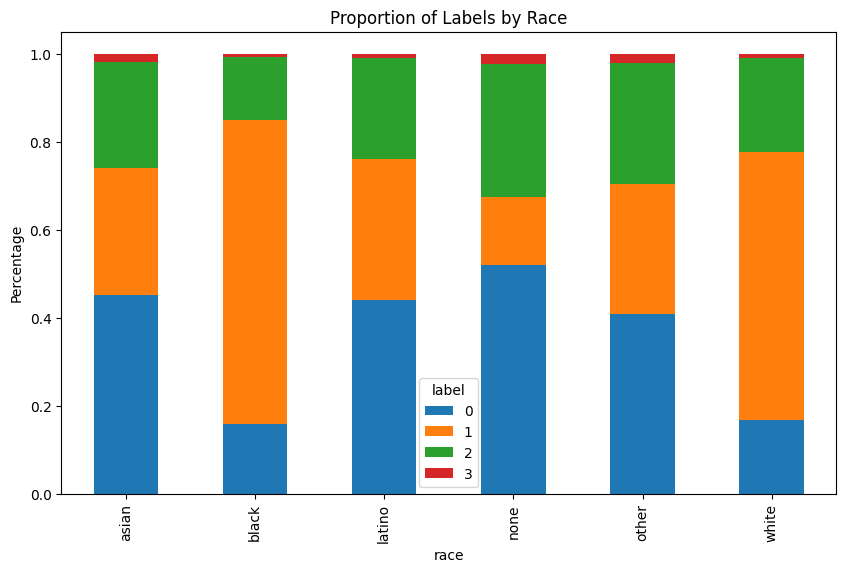

In [13]:
pd.crosstab(train_df['race'], train_df['label'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(10, 6)
)
plt.title("Proportion of Labels by Race")
plt.ylabel("Percentage")
plt.show()

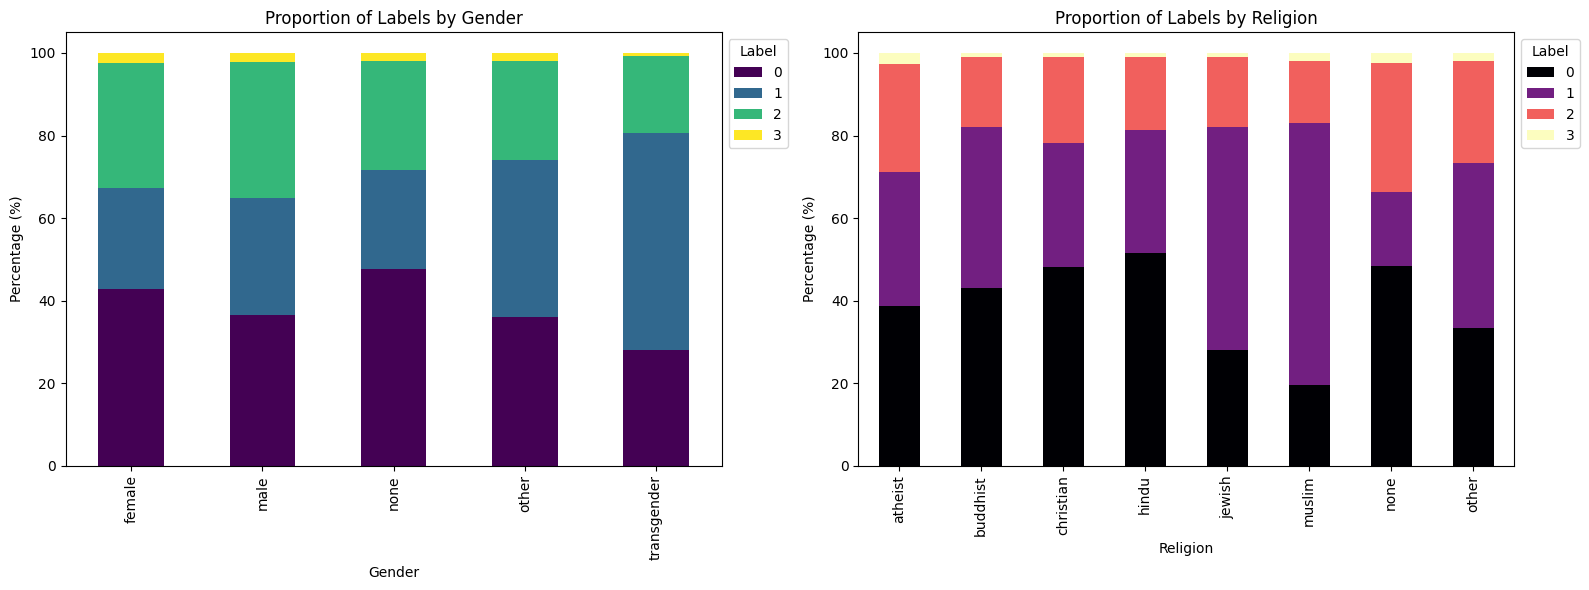

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

gender_label_pct = pd.crosstab(train_df['gender'], train_df['label'], normalize='index') * 100
gender_label_pct.plot(kind='bar', stacked=True, ax=ax[0], colormap='viridis')
ax[0].set_title("Proportion of Labels by Gender")
ax[0].set_ylabel("Percentage (%)")
ax[0].set_xlabel("Gender")
ax[0].legend(title='Label', loc='upper left', bbox_to_anchor=(1, 1))

religion_label_pct = pd.crosstab(train_df['religion'], train_df['label'], normalize='index') * 100
religion_label_pct.plot(kind='bar', stacked=True, ax=ax[1], colormap='magma')
ax[1].set_title("Proportion of Labels by Religion")
ax[1].set_ylabel("Percentage (%)")
ax[1].set_xlabel("Religion")
ax[1].legend(title='Label', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## 3 & 4: Feature-specific Preprocessing (Scaling & Encoding)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

text_feature = "comment_clean"

categorical_features = ["race", "religion", "gender", "disability"]

numeric_features = [
    "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2",
    "year", "month",
    "hour", "day",
    "comment_length", "word_count", "unique_word_count",
    "upvote_ratio", "vote_diff",
    "emoticon_total"
]

preprocessor_boost = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=15000,
                min_df=5,
                max_df = 0.9,
                ngram_range=(1, 2),
                sublinear_tf = True,
                stop_words = "english"
            ),
            text_feature
        ),
        (
            "char_tfidf",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(3,5),
                min_df=5,
                max_features=5000
            ),
            text_feature
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_trans = preprocessor_boost.fit_transform(X_train)
X_val_trans   = preprocessor_boost.transform(X_val)
X_test_trans  = preprocessor_boost.transform(X_test)  

## Logictic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

logreg = LogisticRegression(
    C=0.5,
    class_weight='balanced',
    solver='saga',
    penalty='l2',
    max_iter=1000,
    n_jobs=-1,
    random_state=42,
)

logreg.fit(X_train_trans, y_train)
y_val_pred_lr = logreg.predict(X_val_trans)

print("Logistic Regression f1 (macro):", f1_score(y_val, y_val_pred_lr, average='macro'))
print(classification_report(y_val, y_val_pred_lr))

Logistic Regression f1 (macro): 0.6320450740139023
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.45      0.82      0.58      3183
           2       0.82      0.69      0.75     12488
           3       0.29      0.22      0.25      1094

    accuracy                           0.83     39600
   macro avg       0.63      0.67      0.63     39600
weighted avg       0.86      0.83      0.84     39600



## Hyperparameter tuning with SGDClassifier + GridSearchCV

In [17]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

sgd = SGDClassifier(
    loss='modified_huber',
    class_weight='balanced',
    random_state=42
)

param_grid = [
    {
        "alpha":[1e-4, 1e-3],
        'learning_rate':["optimal"],
        "penalty":["l2","elasticnet"],
    },
    {
        "alpha":[1e-4,1e-3],
        "eta0":[0.001],
        "learning_rate":['adaptive'],
        "penalty":["l2","elasticnet"]
    },
]

grid_sgd = GridSearchCV(
    estimator=sgd,
    param_grid = param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_sgd.fit(X_train_trans, y_train)

print("Best SGD params:", grid_sgd.best_params_)
print("Best SGD CV F1:", grid_sgd.best_score_)

y_val_pred_sgd = grid_sgd.predict(X_val_trans)
print("Tuned SGD F1 (macro):", f1_score(y_val, y_val_pred_sgd, average="macro"))
print(classification_report(y_val, y_val_pred_sgd))

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic

Best SGD params: {'alpha': 0.0001, 'eta0': 0.001, 'learning_rate': 'adaptive', 'penalty': 'l2'}
Best SGD CV F1: 0.5329895316277279
Tuned SGD F1 (macro): 0.5387015666870393
              precision    recall  f1-score   support

           0       0.95      0.66      0.78     22835
           1       0.42      0.71      0.53      3183
           2       0.61      0.80      0.69     12488
           3       0.12      0.22      0.15      1094

    accuracy                           0.70     39600
   macro avg       0.53      0.60      0.54     39600
weighted avg       0.78      0.70      0.71     39600



# LGBMClassifier

In [18]:
from lightgbm import LGBMClassifier

lgbm_tuned = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=96,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_samples=30,
    class_weight="balanced",
    random_state=42,
    max_bin=63,
    reg_alpha=0.5,
    reg_lambda=0.5
)

lgbm_tuned.fit(X_train_trans, y_train)
y_val_pred_lgbm = lgbm_tuned.predict(X_val_trans)

print("Tuned LightGBM f1 (macro):", f1_score(y_val, y_val_pred_lgbm, average='macro'))
print(classification_report(y_val, y_val_pred_lgbm))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 39.960930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 811983
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 19884
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Tuned LightGBM f1 (macro): 0.8281948527001012
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.84      0.79      3183
           2       0.88      0.90      0.89     12488
           3       0.67      0.67      0.67      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.84      0.83     39600
weighted avg       0.92      0.92      0.92     39600



# MultinomialNb

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_simple = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english",
)

X_train_tfidf = tfidf_simple.fit_transform(X_train["comment_clean"])
X_val_tfidf   = tfidf_simple.transform(X_val["comment_clean"])

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_val_pred_nb = nb.predict(X_val_tfidf)

print("MultinomialNB F1 (macro):", f1_score(y_val, y_val_pred_nb, average="macro"))
print(classification_report(y_val, y_val_pred_nb))

MultinomialNB F1 (macro): 0.48961377488466185
              precision    recall  f1-score   support

           0       0.71      0.92      0.80     22835
           1       0.72      0.39      0.51      3183
           2       0.75      0.50      0.60     12488
           3       0.83      0.03      0.05      1094

    accuracy                           0.72     39600
   macro avg       0.75      0.46      0.49     39600
weighted avg       0.73      0.72      0.69     39600



# LinearSV

In [20]:
from sklearn.svm import LinearSVC

svc = LinearSVC(class_weight="balanced", random_state=42)

svc.fit(X_train_trans, y_train)
y_val_pred_svc = svc.predict(X_val_trans)

print("LinearSVC F1 (macro):", f1_score(y_val, y_val_pred_svc, average="macro"))
print(classification_report(y_val, y_val_pred_svc))


LinearSVC F1 (macro): 0.6703053590143768
              precision    recall  f1-score   support

           0       0.82      0.84      0.83     22835
           1       0.59      0.76      0.67      3183
           2       0.75      0.62      0.68     12488
           3       0.40      0.68      0.51      1094

    accuracy                           0.76     39600
   macro avg       0.64      0.72      0.67     39600
weighted avg       0.77      0.76      0.76     39600



# KNeighborsClassifier

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1,
)

knn.fit(X_train_trans, y_train)
y_val_pred_knn = knn.predict(X_val_trans)

print("KNN F1 (macro):", f1_score(y_val, y_val_pred_knn, average="macro"))
print(classification_report(y_val, y_val_pred_knn))


KNN F1 (macro): 0.5200615909270457
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     22835
           1       0.44      0.31      0.36      3183
           2       0.71      0.78      0.74     12488
           3       0.13      0.03      0.05      1094

    accuracy                           0.81     39600
   macro avg       0.55      0.51      0.52     39600
weighted avg       0.79      0.81      0.80     39600



# BaggingClassifier

In [22]:
from sklearn.ensemble import BaggingClassifier

bag_logreg = BaggingClassifier(
    estimator=LogisticRegression(
        C=0.5,
        class_weight="balanced",
        solver="liblinear",
        penalty="l2",
        max_iter=1000,
        n_jobs=-1,
        random_state=42,
    ),
    n_estimators=10,
    max_samples=0.8,
    max_features=1.0,
    n_jobs=-1,
    random_state=42,
)

bag_logreg.fit(X_train_trans, y_train)
y_val_pred_bag = bag_logreg.predict(X_val_trans)

print("Bagging(LogReg) F1 (macro):", f1_score(y_val, y_val_pred_bag, average="macro"))
print(classification_report(y_val, y_val_pred_bag))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  

Bagging(LogReg) F1 (macro): 0.7869386008062264
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.69      0.78      0.73      3183
           2       0.85      0.86      0.86     12488
           3       0.59      0.63      0.61      1094

    accuracy                           0.89     39600
   macro avg       0.77      0.80      0.79     39600
weighted avg       0.90      0.89      0.89     39600



# VotingClassifier

In [23]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("lr", logreg),
        ("sgd", grid_sgd.best_estimator_ if hasattr(grid_sgd, "best_estimator_") else sgd),
        ("lgbm", lgbm_tuned),
    ],
    voting="hard",
    n_jobs=-1,
)

voting_clf.fit(X_train_trans, y_train)
y_val_pred_vote = voting_clf.predict(X_val_trans)

print("Voting F1 (macro):", f1_score(y_val, y_val_pred_vote, average="macro"))
print(classification_report(y_val, y_val_pred_vote))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 67.068951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 811983
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 19884
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Voting F1 (macro): 0.6954957190788605
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     22835
           1       0.55      0.80      0.65      3183
           2       0.83      0.80      0.81     12488
           3       0.52      0.28      0.36      1094

    accuracy                           0.87     39600
   macro avg       0.72      0.71      0.70     39600
weighted avg       0.88      0.87      0.87     39600



## Model Comparison and Parameter Strategy 

In [24]:
results = pd.DataFrame([
    ["Logistic Regression",     f1_score(y_val, y_val_pred_lr,   average="macro")],
    ["SGD (tuned)",             f1_score(y_val, y_val_pred_sgd,  average="macro")],
    ["MultinomialNB",           f1_score(y_val, y_val_pred_nb,   average="macro")],
    ["LinearSVC",               f1_score(y_val, y_val_pred_svc,  average="macro")],
    ["KNN",                     f1_score(y_val, y_val_pred_knn,  average="macro")],
    ["Bagging(LogReg)",         f1_score(y_val, y_val_pred_bag,  average="macro")],
    ["Voting (LR+SGD+LGBM)",    f1_score(y_val, y_val_pred_vote, average="macro")],
    ["LightGBM tuned",          f1_score(y_val, y_val_pred_lgbm, average="macro")],
], columns=["Model", "F1_macro"]).sort_values("F1_macro", ascending=False)

results


,Model,F1_macro
7,LightGBM tuned,0.828195
5,Bagging(LogReg),0.786939
6,Voting (LR+SGD+LGBM),0.695496
3,LinearSVC,0.670305
0,Logistic Regression,0.632045
1,SGD (tuned),0.538702
4,KNN,0.520062
2,MultinomialNB,0.489614


# Best model fitting

In [25]:
lgbmtuned = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=96,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_samples=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    max_bin=63,
    reg_alpha=0.5,
    reg_lambda=0.5,
)

lgbmfinal = Pipeline(
    steps=[
        ("preprocessor", preprocessor_boost), 
        ("model", lgbmtuned),
    ]
)


lgbmfinal.fit(X, y)
print("Final LightGBM trained on full data")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 46.816398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 874964
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 20025
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Final LightGBM trained on full data


# Automated Hyperparameter Optimization

# 5: Comparative Analysis & Key Takeaways

We evaluated multiple models on the validation set using macro F1-score to account for label imbalance. The table below summarises the results, sorted from best to worst performance:

| Model                   | Macro F1-score   |
|-------------------------|----------------  |
| LightGBM tuned          | 0.828            |
| Bagging (LogisticReg)   | 0.786            |
| Voting (LR + SGD + LGBM)| 0.695            |
| Logistic Regression     | 0.632            |
| SGD (tuned)             | 0.538            |
| LinearSVC               | 0.670            |
| MultinomialNB           | 0.489            |
| KNN                     | 0.520            |

LightGBM with tuned hyperparameters achieved the highest macro F1, showing that tree-based boosting is highly effective for this task. Linear baselines (Logistic Regression, tuned SGD, LinearSVC) still performed competitively, confirming that the TF–IDF + metadata feature space is well-suited to linear decision boundaries.

### 5.2 What Worked Well

- Rich text representation combining word- and character-level TF–IDF, along with categorical and numeric metadata, significantly improved model performance compared to text-only baselines.
- Class-weighted training (`class_weight="balanced"`) consistently boosted macro F1 by giving more importance to minority toxicity levels.
- Ensemble methods, especially Bagging(LogReg) and the Voting classifier, provided gains over single linear models by reducing variance and leveraging model diversity.

### 5.3 Limitations and Observations

- Distance-based KNN struggled in the very high-dimensional sparse feature space, leading to relatively lower macro F1 and high computational cost at inference.
- Multinomial Naive Bayes, while fast and simple, underperformed compared to tuned linear and boosting models, indicating that its independence assumptions are too restrictive for this problem.
- Hard voting did not outperform the best individual model (LightGBM), suggesting that simply combining models is not always better than a well-tuned single strong learner.

### 5.4 Final Choice and Justification

Given the comparative results, tuned LightGBM was selected as the final model. It offers the best trade-off between macro F1-score, robustness to class imbalance, and ability to exploit heterogeneous features. The final deployed pipeline wraps the full preprocessing `ColumnTransformer` and the tuned LightGBM classifier, ensuring a clean, reproducible end-to-end workflow from raw inputs to predictions.

In [26]:

feature_cols = [
    "comment_clean",
    "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2",
    "race", "religion", "gender", "disability",
    "year", "month",
    "hour", "day",
    "comment_length", "word_count", "unique_word_count",
    "upvote_ratio", "vote_diff",
    "emoticon_total"
]

X_test = test_df[feature_cols]
print(X_test.shape)
test_predictions_lgbm = lgbmfinal.predict(X_test)

(102000, 22)


In [27]:

sample_submission = pd.read_csv(
    "/kaggle/input/comment-category-prediction-challenge/Sample.csv"
)


sample_submission["label"] = test_predictions_lgbm


sample_submission.to_csv("/kaggle/working/submission.csv", index=False)

sample_submission.head()


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


In [28]:
import os
print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'submission.csv']


In [29]:
print("Submission shape:", sample_submission.shape)
print("Unique labels:", np.unique(sample_submission["label"]))


Submission shape: (102000, 2)
Unique labels: [0 1 2 3]


# Milestone 1

In [30]:
# print(train_df.shape)
# print(test_df.shape[1])
# print(train_df.select_dtypes(include=['object']).shape[1])
# print(train_df.select_dtypes(exclude=['object']).shape[1])
# print(train_df.select_dtypes(include=['bool']).columns)
# print(train_df[['comment', 'race', 'religion', 'gender']].isnull().sum())
# print(train_df['label'].value_counts())

# median_upvotes = train_df['upvote'].median()
# print(f"The median number of upvotes is: {median_upvotes}")

# print(train_df[['upvote', 'downvote', 'if_1', 'if_2']].max())
# print("Minimum of if_2:", train_df['if_2'].min())

In [31]:

# counts = train_df['label'].value_counts()


# percentages = train_df['label'].value_counts(normalize=True) * 100

# print("Counts per label:\n", counts)
# print("\nPercentage per label:\n", percentages)


# label_0_perc = percentages.get(0)
# print(f"\nApproximate percentage of Label 0: {label_0_perc:.2f}%")

# Milestone 2

In [32]:

# whitespace_missing = train_df[train_df['comment'].str.strip() == ""].shape[0]

# print(f"Rows with only whitespace: {whitespace_missing}")

In [33]:
# # 1. Convert to datetime
# train_df['created_date'] = pd.to_datetime(train_df['created_date'])

# # 2. Extract month name and find the most frequent (mode)
# most_frequent_month = train_df['created_date'].dt.month_name().str.lower().mode()[0]

# print(f"The month that occurs the most is: {most_frequent_month}")

In [34]:
# # 1. Create the new feature
# train_df['total_emoticons'] = train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']

# # 2. Find the maximum value
# max_emoticons = train_df['total_emoticons'].max()

# print(f"The maximum value of total_emoticons is: {max_emoticons}")

In [35]:
# # 1. Fill missing comments with empty strings to avoid errors
# train_df['comment'] = train_df['comment'].fillna("")

# # 2. Filter the dataframe for rows where label is 3
# label_3_comments = train_df[train_df['label'] == 3]['comment']

# # 3. Calculate the length of each comment in this subset
# lengths_label_3 = label_3_comments.apply(len)

# # 4. Find the median
# median_len_3 = lengths_label_3.median()

# print(f"The median character length for label 3 is: {median_len_3}")

In [36]:
# # 1. Fill missing comments with empty strings
# train_df['comment'] = train_df['comment'].fillna("")

# # 2. Lowercase and tokenize by whitespace
# # We use a set to automatically handle uniqueness
# unique_tokens = set()

# for comment in train_df['comment']:
#     # .split() without arguments handles all whitespace (spaces, tabs, newlines)
#     tokens = comment.lower().split()
#     unique_tokens.update(tokens)

# # 3. Get the total count
# vocab_size = len(unique_tokens)
# print(f"Total number of unique tokens: {vocab_size}")

In [37]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # 1. Fill missing comments
# train_df['comment'] = train_df['comment'].fillna("")

# # 2. Initialize the Vectorizer with your specific parameters
# # Note: We do NOT set max_features here so we can see the total generated
# vectorizer = TfidfVectorizer(
#     stop_words='english',
#     min_df=5,
#     ngram_range=(1, 2)
# )

# # 3. Fit and transform the comment column
# tfidf_matrix = vectorizer.fit_transform(train_df['comment'])

# # 4. Get the number of features
# num_features = tfidf_matrix.shape[1]
# print(f"Total TF-IDF features generated: {num_features}")

In [38]:
# # 1. Handle missing values
# # We replace NaNs with empty strings to avoid attribute errors
# comments_clean = train_df['comment'].fillna("").astype(str)

# # 2. Compute unique tokens using a set for efficiency
# unique_tokens = set()
# for comment in comments_clean:
#     # .lower() converts to lowercase
#     # .split() tokenizes by any whitespace (space, tab, newline)
#     words = comment.lower().split()
#     unique_tokens.update(words)

# # 3. Get the total count
# print(f"Total unique tokens: {len(unique_tokens)}")

In [39]:
# import string

# # 1. Get the first comment (Index 0)
# text = str(train_df.iloc[0]['comment'])

# # 2. Remove Punctuation
# # We use string.punctuation which includes !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
# translator = str.maketrans('', '', string.punctuation)
# text_no_punct = text.translate(translator)

# # 3. Tokenize (Split by whitespace) and convert to lowercase
# words = text_no_punct.lower().split()

# # 4. Define Stop Words
# stop_words = [
#     'a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 
#     'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 
#     'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
#     'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 
#     'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 
#     'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your'
# ]

# # 5. Remove Stop Words
# filtered_words = [w for w in words if w not in stop_words]

# print(f"Original word count: {len(words)}")
# print(f"Words left after operations: {len(filtered_words)}")

# Milestone 3

In [40]:
# # Option 1: The most direct way
# print(len(train_df))

# # Option 2: Checking the shapes directly after your split
# print(X_train.shape[0] + X_val.shape[0])

In [41]:
# # 1. Convert date in the ORIGINAL dataframe first
# train_df['created_date'] = pd.to_datetime(train_df['created_date'])

# # 2. Use the index of X_train to pull the dates from the original dataframe
# train_months = train_df.loc[X_train.index, 'created_date'].dt.month_name()

# # 3. Get the mode and lowercase it
# most_frequent_month = train_months.mode()[0].lower()
# print(most_frequent_month)

In [42]:
# from sklearn.preprocessing import OneHotEncoder
# import pandas as pd

# # 1. Impute categorical columns with 'none'
# categorical_cols = ['religion', 'gender', 'race']
# X_train[categorical_cols] = X_train[categorical_cols].fillna('none')
# X_val[categorical_cols] = X_val[categorical_cols].fillna('none')

# # 2. Initialize OneHotEncoder
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# # 3. Fit and Transform the specific columns
# encoded_features = ohe.fit_transform(X_train[categorical_cols])

# # 4. Create a DataFrame from the encoded features with proper column names
# encoded_df = pd.DataFrame(encoded_features, 
#                           columns=ohe.get_feature_names_out(categorical_cols), 
#                           index=X_train.index)

# # 5. Drop original columns and concatenate the new encoded ones
# X_train_final = X_train.drop(columns=categorical_cols).join(encoded_df)

# # The answer is the number of columns in this final dataframe
# print(f"The value of b is: {X_train_final.shape[1]}")

# Milestone 4

In [43]:
# X_train_a, X_val_a, y_train_a, y_val_a = train_test_split(
#     X, y, test_size=0.40, random_state=2306, stratify=y
# )

# train_counts_a = y_train_a.value_counts().sort_index().to_numpy()
# val_counts_a = y_val_a.value_counts().sort_index().to_numpy()

# X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
#     X, y, test_size=0.40, random_state=2306, stratify=None
# )

# train_counts_b = y_train_b.value_counts().sort_index().to_numpy()
# val_counts_b = y_val_b.value_counts().sort_index().to_numpy()


# prop_a = val_counts_a / val_counts_a.sum()
# prop_b = val_counts_b / val_counts_b.sum()

# abs_diffs = np.abs(prop_a - prop_b)

# max_diff = np.max(abs_diffs)

# print(f"Maximum absolute difference in proportions: {max_diff:.6f}")